In [1]:
import numpy as np
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from bluepysnap import Circuit
from bluepysnap.bbp import Cell

# CircuitPath = 'O1_data_physiology/' # edges files not inclued in https://github.com/FernandoSBorges/

CircuitPath = 'O1_data_physiology/'
MorphologyPath = CircuitPath + 'morphologies/ascii/'
CellLibraryFile = CircuitPath + 'S1nonbarrel_neurons/nodes.h5'
METypePath = CircuitPath + 'emodels_hoc/'
circuit_path = CircuitPath + 'circuit_config.json'
circuit = Circuit(circuit_path)

cells = circuit.nodes["S1nonbarrel_neurons"]

nodesinfo = cells.get()

def distance3D(gidpre,gidpost):
    return np.sqrt(np.power(nodesinfo['x'][gidpre]-nodesinfo['x'][gidpost],2)+np.power(nodesinfo['y'][gidpre]-nodesinfo['y'][gidpost],2)+np.power(nodesinfo['z'][gidpre]-nodesinfo['z'][gidpost],2))

def distance2D(gidpre,gidpost):
    return np.sqrt(np.power(nodesinfo['x'][gidpre]-nodesinfo['x'][gidpost],2)+np.power(nodesinfo['y'][gidpre]-nodesinfo['y'][gidpost],2))

def distance2Dmean(gidpre, mean_x, mean_y):
    return np.sqrt(np.power(nodesinfo['x_new'][gidpre]-mean_x,2)+np.power(nodesinfo['y_new'][gidpre]-mean_y,2))


mtypes = sorted(cells.property_values(Cell.MTYPE))

i = 0
mntypes = {}
for mn in sorted(mtypes):
    mntypes[mn] = i
    i+=1

print(mntypes)

{'L1_DAC': 0, 'L1_HAC': 1, 'L1_LAC': 2, 'L1_NGC-DA': 3, 'L1_NGC-SA': 4, 'L1_SAC': 5, 'L23_BP': 6, 'L23_BTC': 7, 'L23_CHC': 8, 'L23_DBC': 9, 'L23_LBC': 10, 'L23_MC': 11, 'L23_NBC': 12, 'L23_NGC': 13, 'L23_SBC': 14, 'L2_IPC': 15, 'L2_TPC:A': 16, 'L2_TPC:B': 17, 'L3_TPC:A': 18, 'L3_TPC:C': 19, 'L4_BP': 20, 'L4_BTC': 21, 'L4_CHC': 22, 'L4_DBC': 23, 'L4_LBC': 24, 'L4_MC': 25, 'L4_NBC': 26, 'L4_NGC': 27, 'L4_SBC': 28, 'L4_SSC': 29, 'L4_TPC': 30, 'L4_UPC': 31, 'L5_BP': 32, 'L5_BTC': 33, 'L5_CHC': 34, 'L5_DBC': 35, 'L5_LBC': 36, 'L5_MC': 37, 'L5_NBC': 38, 'L5_NGC': 39, 'L5_SBC': 40, 'L5_TPC:A': 41, 'L5_TPC:B': 42, 'L5_TPC:C': 43, 'L5_UPC': 44, 'L6_BP': 45, 'L6_BPC': 46, 'L6_BTC': 47, 'L6_CHC': 48, 'L6_DBC': 49, 'L6_HPC': 50, 'L6_IPC': 51, 'L6_LBC': 52, 'L6_MC': 53, 'L6_NBC': 54, 'L6_NGC': 55, 'L6_SBC': 56, 'L6_TPC:A': 57, 'L6_TPC:C': 58, 'L6_UPC': 59}


## Select nodes to simulate

In [2]:
f = open('node_sets.json') 
node_sets = json.load(f) 

mean_x, mean_y = np.mean(nodesinfo['x_new']), np.mean(nodesinfo['y_new'])
node_gid = [] 
nodepremtype_new = []    
mtype_new = []     
node_gid = []
hoclist = []
Morpholist = []
node_threshold_current = []
node_holding_current = []
hex = 'hex0'
for gid in [108767,141766, 138433, 141369, 138906, 113319, 109685]:
#     if 'L4_' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y) > 0.0 and distance2Dmean(gid, mean_x, mean_y) < 50.0 and 'EXC' in nodesinfo['synapse_class'][gid]:  
#         if 'dend-C010398B' in nodesinfo['morphology'][gid] or 'dend-C170898A' in nodesinfo['morphology'][gid]:
            nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
            if nodesinfo['mtype'][gid] not in mtype_new:
                mtype_new.append(nodesinfo['mtype'][gid])

            print(len(node_gid),gid,nodesinfo['synapse_class'][gid],nodesinfo['mtype'][gid],nodesinfo['model_template'][gid],nodesinfo['morphology'][gid],hex)
            current1 = cells.get(gid,['@dynamics:threshold_current']).values[0]
            holding_current1 = cells.get(gid,['@dynamics:holding_current']).values[0]
            # print("%d %.5f %.5f" % (gid,current1,holding_current1))
            node_gid.append(gid)
            hoclist.append(nodesinfo['model_template'][gid][4:])
            Morpholist.append(nodesinfo['morphology'][gid])
            node_threshold_current.append(current1)
            node_holding_current.append(holding_current1)


0 108767 INH L4_BP hoc:cNAC_L6NGC rp140319_ChC_3_idA_-_Scale_x1.000_y0.950_z1.000_-_Clone_1 hex0
1 141766 INH L4_BTC hoc:cNAC_L6NGC rp110127_L5-2_idG_-_Scale_x1.000_y0.950_z1.000 hex0
2 138433 INH L4_NBC hoc:cNAC_L6NGC rp110131_L5-1_idA_-_Scale_x1.000_y1.025_z1.000_-_Clone_0 hex0
3 141369 EXC L4_SSC hoc:cADpyr_L4TPC dend-rp120608_P_3_idD_axon-sm100429a1-5_INT_idG_-_Scale_x1.000_y1.050_z1.000_-_Clone_0 hex0
4 138906 EXC L4_SSC hoc:cADpyr_L4TPC dend-C120398A-P1_axon-rp120608_P_3_idD_-_Scale_x1.000_y1.050_z1.000_-_Clone_1 hex0
5 113319 EXC L4_UPC hoc:cADpyr_L4UPC dend-C170898A-P3_axon-C180997A-P3_-_Scale_x1.000_y1.025_z1.000_-_Clone_0 hex0
6 109685 EXC L4_UPC hoc:cADpyr_L4TPC dend-C010398B-P3_axon-rp120722_L4-1_idF_-_Scale_x1.000_y0.975_z1.000 hex0


# NetPyNE

In [3]:
from netpyne import specs, sim   

# Network parameters
netParams = specs.NetParams()  # object of class NetParams to store the network parameters

In [4]:
cellName_list = {}
cellName_list2 = []
gid_list = {}

Epops = []
Ipops = []

cellName_list2 = []

for gid in node_gid:

    cellName = nodesinfo['mtype'][gid] + '_' + nodesinfo['etype'][gid]
        
    cellName_list2.append(cellName)
    
    cellName_list[gid] = cellName + '_' + str(len(cellName_list2)-1)
    gid_list[cellName + '_' + str(len(cellName_list2)-1)] = gid
    
    print('%s %s %s 1 1 %d' % (cellName + '_' + str(len(cellName_list2)-1),nodesinfo['mtype'][gid],nodesinfo['etype'][gid],gid))

    if 'cADpyr' in cellName:
        Epops.append(cellName + '_' + str(len(cellName_list2)-1))
    else:
        Ipops.append(cellName + '_' + str(len(cellName_list2)-1))

L4_BP_cNAC_0 L4_BP cNAC 1 1 108767
L4_BTC_cNAC_1 L4_BTC cNAC 1 1 141766
L4_NBC_cNAC_2 L4_NBC cNAC 1 1 138433
L4_SSC_cADpyr_3 L4_SSC cADpyr 1 1 141369
L4_SSC_cADpyr_4 L4_SSC cADpyr 1 1 138906
L4_UPC_cADpyr_5 L4_UPC cADpyr 1 1 113319
L4_UPC_cADpyr_6 L4_UPC cADpyr 1 1 109685


In [5]:
cellsList = {}
# sections_soma = {}
# sections_dend = {}
for cellName in gid_list.keys():
    # try:
        # if not cellName.startswith('L4_SSC'):
        #         continue

    
        gid = gid_list[cellName]

        MorphoName = nodesinfo['morphology'][gid] + '.asc'

        hocName = nodesinfo['model_template'][gid][4:]  

        MorphologyPath = 'O1_data_physiology/morphologies/ascii'
        
        # MorphoName = nodesinfo['morphology'][gid]+"_gid"+str(gid)+".asc"

        print(cellName,hocName)
            
        cellRule = netParams.importCellParams(label=cellName, somaAtOrigin=True,
            conds={'cellType': cellName, 'cellModel': 'HH_full'},
            fileName='O1_data_physiology/emodels_hoc/' + hocName + '.hoc',
            cellName=hocName,
            cellInstance = False,
            cellArgs=[gid, MorphologyPath, MorphoName])
        
        # netParams.saveCellParamsRule(label=cellName, fileName=cellName+'_BBP_cellParams.json')

        cellsList[cellName] = [{'x': nodesinfo['x'][gid], 'y': nodesinfo['y'][gid], 'z': nodesinfo['z'][gid]}]
        # cellsList[cellName] = [{'x': nodesinfo['x'][gid] - 3000.0, 'y': nodesinfo['y'][gid] + 2000.0, 'z': nodesinfo['z'][gid] + 3500.0}]

        cellMe = cellName
        
        # sections_soma[cellMe] = []
        # sections_soma[cellMe].append('soma_0')
        # for sec in netParams.cellParams[cellMe]['secs'].keys():
        #     if netParams.cellParams[cellMe]['secs'][sec]['topol']['parentSec'] == 'soma_0' and 'axon' not in sec and netParams.cellParams[cellMe]['secs'][sec]['geom']['L'] < 30.0:
        #         # print(cellMe,sec,netParams.cellParams[cellMe]['secs'][sec]['topol']['parentSec'],netParams.cellParams[cellMe]['secs'][sec]['geom']['L'])
        #         sections_soma[cellMe].append(sec)

        # sections_dend[cellMe] = []
        # for sec in netParams.cellParams[cellMe]['secs'].keys():
        #     if netParams.cellParams[cellMe]['secs'][sec]['topol']['parentSec'] != 'soma_0' and sec not in sections_soma[cellMe] and 'soma_0' not in sec and 'axon' not in sec and 'mye' not in sec:
        #         # print(cellMe,sec,netParams.cellParams[cellMe]['secs'][sec]['topol']['parentSec'])
        #         sections_dend[cellMe].append(sec)

        # netParams.cellParams[cellMe]['secLists']['somaList'] = list(sections_soma[cellMe])
        # netParams.cellParams[cellMe]['secLists']['dendList'] = list(sections_dend[cellMe])

        axon_pt3d_x, axon_pt3d_y, axon_pt3d_z, soma_pt3d_diam =  netParams.cellParams[cellMe]['secs']['soma_0']['geom']['pt3d'][-1]

        if cellName in Ipops:
            netParams.cellParams[cellName]['secs']['axon_0']['geom']['diam'] = 2.0
        else:
            netParams.cellParams[cellName]['secs']['axon_0']['geom']['diam'] = 1.0
        # netParams.cellParams[cellMe]['secs']['axon_0']['geom']['L'] = 30.0

        axon_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['diam']
        axon_pt3d_L =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['L']

        netParams.cellParams[cellMe]['secs']['axon_0']['geom']['pt3d'] = [(axon_pt3d_x, axon_pt3d_y, axon_pt3d_z, axon_pt3d_diam),
                                                                                    (axon_pt3d_x, axon_pt3d_y+axon_pt3d_L/2.0, axon_pt3d_z, axon_pt3d_diam),
                                                                                    (axon_pt3d_x, axon_pt3d_y+axon_pt3d_L, axon_pt3d_z, axon_pt3d_diam)]



        axon1_pt3d_x, axon1_pt3d_y, axon1_pt3d_z, axon_0_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['pt3d'][-1]

        netParams.cellParams[cellMe]['secs']['axon_1']['geom']['diam'] = 0.5
        # netParams.cellParams[cellMe]['secs']['axon_1']['geom']['L'] = 30.0

        axon1_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['diam']
        axon1_pt3d_L =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['L']

        netParams.cellParams[cellMe]['secs']['axon_1']['geom']['pt3d'] = [(axon1_pt3d_x, axon1_pt3d_y, axon1_pt3d_z, axon1_pt3d_diam),
                                                                                    (axon1_pt3d_x, axon1_pt3d_y+axon1_pt3d_L/2.0, axon1_pt3d_z, axon1_pt3d_diam),
                                                                                    (axon1_pt3d_x, axon1_pt3d_y+axon1_pt3d_L, axon1_pt3d_z, axon1_pt3d_diam)] 


                    
        myelin_pt3d_x, myelin_pt3d_y, myelin_pt3d_z, axon_1_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['pt3d'][-1]

        netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['diam'] = 0.5
        netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['L'] = 100.0

        myelin_pt3d_diam =  netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['diam']
        myelin_pt3d_L =  netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['L']

        netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['pt3d'] = [(myelin_pt3d_x, myelin_pt3d_y, myelin_pt3d_z, myelin_pt3d_diam),
                                                                                    (myelin_pt3d_x, myelin_pt3d_y+myelin_pt3d_L/2.0, myelin_pt3d_z, myelin_pt3d_diam),
                                                                                    (myelin_pt3d_x, myelin_pt3d_y+myelin_pt3d_L, myelin_pt3d_z, myelin_pt3d_diam)] 

    # except:
    #     pass        

# cellsList

L4_BP_cNAC_0 cNAC_L6NGC
L4_BTC_cNAC_1 cNAC_L6NGC
L4_NBC_cNAC_2 cNAC_L6NGC
L4_SSC_cADpyr_3 cADpyr_L4TPC
L4_SSC_cADpyr_4 cADpyr_L4TPC
L4_UPC_cADpyr_5 cADpyr_L4UPC
L4_UPC_cADpyr_6 cADpyr_L4TPC


In [6]:
# https://github.com/suny-downstate-medical-center/S1_mouse
# Layer	     height	  from	  to
# L1         0.089      0.000	0.089
# L2         0.070      0.089	0.159
# L3         0.128      0.159	0.286
# L4         0.134      0.286	0.421
# L5         0.263      0.421	0.684
# L6         0.316      0.684	1.000			 
# L23        0.198      0.089	0.286
# All     1378.8 um

layer = {'1':[0.0, 0.089], '2': [0.089,0.159], '3': [0.159,0.286], '23': [0.089,0.286], '4':[0.286,0.421], '5': [0.421,0.684], '6': [0.684,1.0], 
'longS1': [2.2,2.3], 'longS2': [2.3,2.4]}  # normalized layer boundaries

#Th pop
ymin={'ss_RTN_o': 1688, 'ss_RTN_m': 1766, 'ss_RTN_i': 1844, 'VPL_sTC': 2000, 'VPM_sTC': 2156, 'POm_sTC_s1': 2312}
ymax={'ss_RTN_o': 1766, 'ss_RTN_m': 1844, 'ss_RTN_i': 2000, 'VPL_sTC': 2156, 'VPM_sTC': 2312, 'POm_sTC_s1': 2624}

#------------------------------------------------------------------------------
# General network parameters
#------------------------------------------------------------------------------
netParams.scale = 1.0 # Scale factor for number of cells
netParams.sizeX = 200.0 # x-dimension (horizontal length) size in um
netParams.sizeY = 2080.0 # y-dimension (vertical height or cortical depth) size in um
netParams.sizeZ = 200.0 # z-dimension (horizontal depth) size in um
netParams.shape = 'cylinder' # cylindrical (column-like) volume
netParams.rotateCellsRandomly = True
   
netParams.defaultThreshold = -20.0 # spike threshold, 10 mV is NetCon default, lower it for all cells
# netParams.defaultDelay = 0.1 # default conn delay (ms)
netParams.propVelocity = 300.0 #  300 μm/ms (Stuart et al., 1997)
netParams.scaleConnWeightNetStims = 0.001  # weight conversion factor (from nS to uS)
    
#------------------------------------------------------------------------------
# load data from S1 Raster
#------------------------------------------------------------------------------
for metype in netParams.cellParams.keys():        
    layernumber = metype[1:2]
    if layernumber == '2':
        netParams.popParams[metype] = {'cellType': metype, 'cellModel': 'HH_full', 'ynormRange': layer['23'], 
                                            'numCells':2, 'diversity': True}
    else:
        netParams.popParams[metype] = {'cellType': metype, 'cellModel': 'HH_full', 'ynormRange': layer[layernumber], 
                                            'numCells': 2, 'diversity': True}

In [7]:
#------------------------------------------------------------------------------
#
# SIMULATION CONFIGURATION
#
#------------------------------------------------------------------------------

cfg = specs.SimConfig()					            # object of class SimConfig to store simulation configuration

cfg.coreneuron = False

#------------------------------------------------------------------------------
# Run parameters
#------------------------------------------------------------------------------
cfg.duration = 600 ## Duration of the sim, in ms  
cfg.dt = 0.025
cfg.seeds = {'cell': 1234, 'conn': 1234, 'stim': 1234, 'loc': 1234} 
cfg.hParams = {'celsius': 34, 'v_init': -74.0}  
cfg.verbose = False
cfg.createNEURONObj = True
cfg.createPyStruct = True  
cfg.cvode_active = False
cfg.cvode_atol = 1e-6
cfg.cache_efficient = True
cfg.printRunTime = 0.1

cfg.includeParamsLabel = False
cfg.printPopAvgRates = True
cfg.checkErrors = False

#--------------------------------------------------------------------------
# Recording 
#--------------------------------------------------------------------------
cfg.recordCells = list(netParams.popParams.keys())
# cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'}}  ## Dict with traces to record  
cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_0': {'sec':'axon_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_1': {'sec':'axon_1', 'loc':0.5, 'var':'v'},
                    # 'V_myelin_0': {'sec':'myelin_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_15': {'sec':'axon_15', 'loc':0.5, 'var':'v'},
                    # 'V_apic_0': {'sec':'apic_0', 'loc':0.5, 'var':'v'},
                    # 'V_apic_47': {'sec':'apic_47', 'loc':0.5, 'var':'v'},       
                    # 'V_apic_64': {'sec':'apic_64', 'loc':0.5, 'var':'v'},
                    # 'V_apic_86': {'sec':'apic_86', 'loc':0.5, 'var':'v'},           
                    # 'V_dend_0': {'sec':'dend_0', 'loc':0.5, 'var':'v'},       
                    # 'V_dend_15': {'sec':'dend_15', 'loc':0.5, 'var':'v'},
                    }
cfg.recordStim = False			
cfg.recordTime = True  		
cfg.recordStep = 0.025       

#------------------------------------------------------------------------------
# Saving
#------------------------------------------------------------------------------
cfg.simLabel = 'v0_batch0'       #   + str(cfg.cynradNumber)
cfg.saveFolder = 'exploration/data/'+cfg.simLabel
# cfg.filename =                	## Set file output name
cfg.savePickle = False	        	## Save pkl file
cfg.saveJson = False           	## Save json file
cfg.saveDataInclude = ['simData', 'simConfig', 'net', 'netParams'] ## ['simData'] ##  ['simData'] ##, , 'simConfig', 'netParams'
cfg.backupCfgFile = None 		##  
cfg.gatherOnlySimData = False	##  
cfg.saveCellSecs = True			
cfg.saveCellConns = True	

#------------------------------------------------------------------------------
# Analysis and plotting 
# ------------------------------------------------------------------------------
# cfg.analysis['plotRaster'] = {'include': cfg.S1cells, 'saveFig': True, 'showFig': False,'orderInverse': True, 'timeRange': [0,cfg.duration], 'figSize': (24,8), 'fontSize':4, 'markerSize':4, 'marker': 'o', 'dpi': 300} 
# cfg.analysis['plot2Dnet']   = {'include': ['presyn_L23_PC_cAD','presyn_L5_TTPC2_cAD', 'presyn_VPM_sTC','L23_PC_cAD','L5_TTPC2_cAD'],'saveFig': True, 'showConns': False, 'figSize': (24,24), 'view': 'xz', 'fontSize':16}   # Plot 2D cells xy
# cfg.analysis['plotTraces'] = {'include': cfg.recordCells, 'oneFigPer': 'trace', 'overlay': True, 'timeRange': [0,cfg.duration], 'ylim': [-100,50], 'saveFig': True, 'showFig': False, 'figSize':(24,24)}

cfg.analysis['plotTraces'] = {'include': [ii for ii in range(len(node_gid))], 'oneFigPer': 'trace', 'overlay': True, 'timeRange': [0,cfg.duration], 'saveFig': False, 'showFig': True, 'figSize':(24,4)} # , 'ylim': [-90,30] Plot recorded traces for this list of cells
# cfg.analysis['plotShape'] = {'includePre':  [ii for ii in range(10)],'includePre':  [ii for ii in range(10)], 'saveFig': True, 'showFig': True, 'figSize':(12,12)}



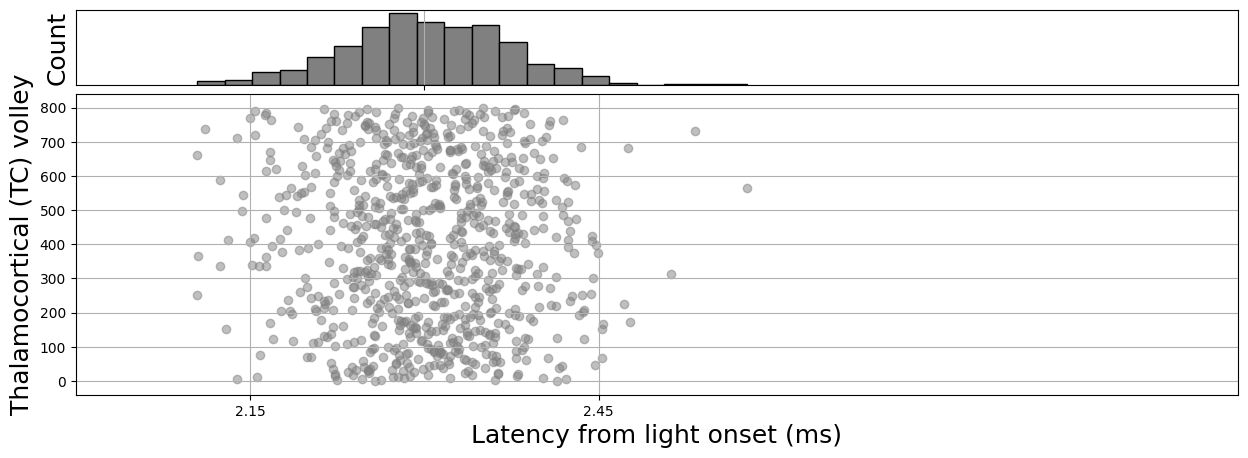

In [8]:
np.random.seed(1)
gaussian = np.random.normal(2.3, 0.07, 800)

fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 4], hspace=0.05)

# Histogram on top
ax_hist = fig.add_subplot(gs[0])
ax_hist.hist(gaussian, bins=20, color='gray', edgecolor='black')
ax_hist.set_xticks([])
ax_hist.set_yticks([])
ax_hist.set_ylabel('Count', size=18)
ax_hist.set_xlim(2, 3.0)
ax_hist.set_xticks([2.3])
ax_hist.grid(True)
# ax_hist.spines['bottom'].set_visible(False)

# Scatter plot below
ax_scatter = fig.add_subplot(gs[1])
ax_scatter.scatter(gaussian, np.arange(len(gaussian)), color='gray', alpha=0.5)
ax_scatter.set_xlabel('Latency from light onset (ms)', size=18)
ax_scatter.set_ylabel('Thalamocortical (TC) volley', size=18)
ax_scatter.set_xticks([0, 2.15, 2.45, 6.0, 10.8, 12])
ax_scatter.set_xlim(2, 3.0)
ax_scatter.grid(True)

plt.show()

In [9]:
#------------------------------------------------------------------------------
# ThVecStim->S1 connectivity parameters
#------------------------------------------------------------------------------
#------------------------------------------------------------------------------  
# Thalamic Cells

cfg.cellNumber = {}
cfg.popLabel = {}
cfg.popNumber = {}
 
cfg.thalamicpops = ['VPM_sTC']
cfg.cellNumber['VPM_sTC'] = 800

for mtype in cfg.thalamicpops: # No diversity
	metype = mtype
	cfg.popLabel[metype] = mtype
	cfg.popNumber[mtype] = cfg.cellNumber[metype]

# create 1 vectstim pop per cell gid
for metype in cfg.thalamicpops: # metype
    cellsList = []            
    for cellLabel in range(cfg.cellNumber[metype]): # all cells in metype

        spike_times = (np.array(gaussian[cellLabel:cellLabel+1]) + 10.0, np.array(gaussian[cellLabel:cellLabel+1]) + 500.0)  # light onset at 500 ms
        # spike_times = np.array(gaussian[cellLabel:cellLabel+1]) + 500.0  # light onset at 500 ms
        cellsList.append({'cellLabel': cellLabel, 'spkTimes': list(spike_times[1:2])})
        # print(cellLabel, spike_times[:2])
        
    if np.size(cellsList) > 0:
        netParams.popParams[metype] = {'cellModel': 'VecStim', 'cellsList': cellsList}        


In [10]:
# data = {}
# data["sections_soma"] = sections_soma 
# data["sections_dend"] = sections_dend

# import json

# with open("sec.json", "w") as f:
#     json.dump(data, f, indent=4)

# print(f"Saved sec.json ({len(data['sections_soma'])} soma, {len(data['sections_dend'])} dend entries)")

In [11]:
json_path = "cells_info_data.json"

with open("cells_info_data.json", "r") as f:
    cells_info = json.load(f)

# assign variables (use empty dicts as fallback)
sections_dend = cells_info.get("sections_dend", {})
sections_soma = cells_info.get("sections_soma", {})

print(f"Loaded sections_dend: {len(sections_dend)} entries, sections_soma: {len(sections_soma)} entries")

Loaded sections_dend: 7 entries, sections_soma: 7 entries


In [12]:
## Th->S1
# J. Neurosci., June 29, 2016 • 36(26):6906 – 6916
# thalamocortical uEPSPs had several-fold larger amplitudes and faster kinetics in FS interneurons compared with excitatory neurons
# amplitude, 1.8 –13.8 vs 0.4 – 0.9 mV; 
# rise time, 0.4 – 0.8 vs 1.3–2.8 ms; 
# decay time constant, 6 –12 vs 17–36 ms
# Th -
netParams.synMechParams['AMPA_Th']             = {'mod': 'MyExp2SynBB',        'tau1': 0.05,   'tau2': 5.3, 'e': 0}
netParams.synMechParams['NMDA_Th']             = {'mod': 'MyExp2SynNMDABB',    'tau1NMDA': 15, 'tau2NMDA': 150,                'e': 0}
ESynMech_Th = ['AMPA_Th', 'NMDA_Th']


cfg.connect_ThVecStim_S1 = True
cfg.TC_S1 = {}
cfg.TC_S1['VPM_sTC'] = True
cfg.TC_S1_weight = {}
cfg.TC_S1_weight['L4_BP_cNAC_0'] = 0.0002
cfg.TC_S1_weight['L4_BTC_cNAC_1'] = 0.0002
cfg.TC_S1_weight['L4_NBC_cNAC_2'] = 0.0002
cfg.TC_S1_weight['L4_SSC_cADpyr_3'] = 0.0001
cfg.TC_S1_weight['L4_SSC_cADpyr_4'] = 0.0001
cfg.TC_S1_weight['L4_UPC_cADpyr_5'] = 0.0003
cfg.TC_S1_weight['L4_UPC_cADpyr_6'] = 0.0001

if cfg.connect_ThVecStim_S1:

    ## Connectivity rules
    synapsesperconnection_Th_S1 = 1*9.0
    for pre in ['VPM_sTC']:  #  
        if cfg.TC_S1[pre]:
            for post in Epops: 
                
                if 'L4_SS' in post:
                    conn_convergence = np.ceil(500/synapsesperconnection_Th_S1)
                else:
                    conn_convergence = np.ceil(450/synapsesperconnection_Th_S1)

                netParams.connParams['thal_'+pre+'_'+post] = { 
                    'preConds': {'pop': pre},  ####################################################
                    'postConds': {'pop': post},
                    'weight': cfg.TC_S1_weight[post],   # synaptic weight 
                    'sec': list(sections_dend[post]), #['basal', 'apical'], # target postsyn section
                    'delay': 0.6,
                    'synsPerConn': int(synapsesperconnection_Th_S1),                     
                    'synMech': ESynMech_Th}  

                netParams.connParams['thal_'+pre+'_'+post]['convergence'] = conn_convergence 
                # netParams.connParams['thal_'+pre+'_'+post]['convergence'] = 1

            for post in Ipops: 
                
                conn_convergence = np.ceil(350/synapsesperconnection_Th_S1)

                netParams.connParams['thal_'+pre+'_'+post] = { 
                    'preConds': {'pop': pre},  ####################################################
                    'postConds': {'pop': post},
                    'weight': cfg.TC_S1_weight[post],   # synaptic weight 
                    'sec': list(sections_soma[post]), # target postsyn section
                    'delay': 0.4,
                    'synsPerConn': int(synapsesperconnection_Th_S1),                     
                    'synMech': ESynMech_Th}  

                netParams.connParams['thal_'+pre+'_'+post]['convergence'] = conn_convergence 
                # netParams.connParams['thal_'+pre+'_'+post]['convergence'] = 1 


In [13]:
cfg.Ipops = Ipops
cfg.Epops = Epops
# Spont and BG
netParams.synMechParams['AMPA'] = {'mod':'MyExp2SynBB', 'tau1': 0.2, 'tau2': 1.74, 'e': 0}
netParams.synMechParams['NMDA'] = {'mod': 'MyExp2SynNMDABB', 'tau1NMDA': 0.29, 'tau2NMDA': 43, 'e': 0}
netParams.synMechParams['GABAA'] = {'mod':'MyExp2SynBB', 'tau1': 0.2, 'tau2': 8.3, 'e': -80}
netParams.synMechParams['GABAB'] = {'mod':'MyExp2SynBB', 'tau1': 3.5, 'tau2': 260.9, 'e': -93} 
ESynMech = ['AMPA', 'NMDA']
ISynMech = ['GABAA', 'GABAB']

cfg.addStimSynS1 = True
cfg.rateStimI = 5.0 # Hz
cfg.rateStimE = 2.0
SourcesNumber = 10 # for each post Mtype - sec distribution

if cfg.addStimSynS1:      
    for post in cfg.Ipops + cfg.Epops:

        synperNeuron = 100
        ratespontaneous = cfg.rateStimI
        for qSnum in range(SourcesNumber):
            ratesdifferentiation = (0.8 + 0.4*qSnum/(SourcesNumber-1)) * (synperNeuron*ratespontaneous)/SourcesNumber
            netParams.stimSourceParams['StimSynS1_S_all_INH->' + post + '_' + str(qSnum)] = {'type': 'NetStim', 'rate': ratesdifferentiation, 'noise': 1.0}

        synperNeuron = 100
        ratespontaneous = cfg.rateStimE
        for qSnum in range(SourcesNumber):
            ratesdifferentiation = (0.8 + 0.4*qSnum/(SourcesNumber-1)) * (synperNeuron*ratespontaneous)/SourcesNumber
            netParams.stimSourceParams['StimSynS1_S_all_EXC->' + post + '_' + str(qSnum)] = {'type': 'NetStim', 'rate': ratesdifferentiation, 'noise': 1.0}
            
    #------------------------------------------------------------------------------
    for post in cfg.Epops+cfg.Ipops:
        for qSnum in range(SourcesNumber):
            netParams.stimTargetParams['StimSynS1_T_all_EXC->' + post + '_' + str(qSnum)] = {
                'source': 'StimSynS1_S_all_EXC->' + post + '_' + str(qSnum), 
                'synMech': 'AMPA', 
                'conds': {'cellType': post}, 
                'sec': 'all', 
                'weight': 0.5,
                'delay': 0.5}

            netParams.stimTargetParams['StimSynS1_T_all_INH->' + post + '_' + str(qSnum)] = {
                'source': 'StimSynS1_S_all_INH->' + post + '_' + str(qSnum), 
                'conds': {'cellType': post}, 
                'synMech': 'GABAA', 
                'sec': 'all', 
                'weight': 0.5,
                'delay': 0.5}
#------------------------------------------------------------------------------

In [14]:
sim.initialize(
    simConfig = cfg, 	
    netParams = netParams)  				# create network object and set cfg and net params
sim.net.createPops()               			# instantiate network populations
sim.net.createCells()              			# instantiate network cells based on defined populations
sim.net.connectCells()            			# create connections between cells based on params
sim.net.addStims() 							# add network stimulation
sim.setupRecording()              			# setup variables to record for each cell (spikes, V traces, etc)
sim.runSim()                      			# run parallel Neuron simulation  
sim.gatherData();                  			# gather spiking data and cell info from each node
# Calcular o firing rate
spk_times = sim.simData['spkt']  # Tempos de spikes
spk_ids = sim.simData['spkid']  # IDs dos neurônios

steps, rates = np.unique(spk_ids, return_counts=True)
# steps, rates/0.6
sim.saveData()                    			# save params, cell info and sim output to file (pickle,mat,txt,etc)#
# sim.analysis.plotData()         			# plot spike raster etc


Start time:  2025-10-21 12:56:01.551624

Creating network of 8 cell populations on 1 hosts...
  Number of cells on node 0: 814 
  Done; cell creation time = 0.80 s.
Making connections...
  Number of connections on node 0: 658 
  Number of synaptic contacts on node 0: 11844 
  Done; cell connection time = 1.70 s.
Adding stims...
  Number of stims on node 0: 280 
  Done; cell stims creation time = 0.19 s.
Recording 14 traces of 1 types on node 0
0.0s

Running simulation using NEURON for 600.0 ms...
0.1s
0.2s
0.3s
0.4s
0.5s
0.6s
  Done; run time = 124.91 s; real-time ratio: 0.00.

Gathering data...
  Done; gather time = 1.33 s.

Analyzing...
  Cells: 814
  Connections: 672 (0.83 per cell)
  Synaptic contacts: 12124 (14.89 per cell)
  Spikes: 853 (1.75 Hz)
  Simulated time: 0.6 s; 1 workers
  Run time: 124.91 s
   L4_BP_cNAC_0 : 9.167 Hz
   L4_BTC_cNAC_1 : 6.667 Hz
   L4_NBC_cNAC_2 : 3.333 Hz
   L4_SSC_cADpyr_3 : 5.000 Hz
   L4_SSC_cADpyr_4 : 5.000 Hz
   L4_UPC_cADpyr_5 : 10.000 Hz
   L4_

[]

In [15]:
cfg.Epops

['L4_SSC_cADpyr_3', 'L4_SSC_cADpyr_4', 'L4_UPC_cADpyr_5', 'L4_UPC_cADpyr_6']

Plotting recorded cell traces ... trace


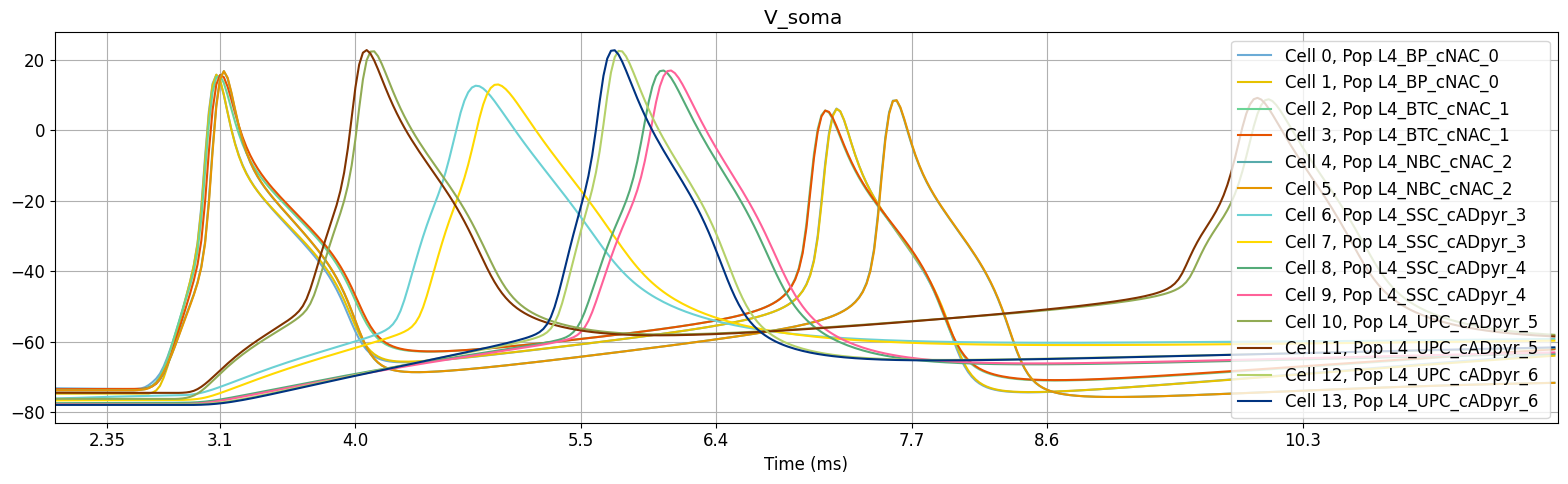

In [16]:
timeRange = [502.0,512]
sim.analysis.plotTraces(include=list(netParams.popParams.keys())[0:7], legend=True, oneFigPer='trace', overlay=True, timeRange=timeRange, saveFig=False, showFig=False, figSize=(16,5));
# plt.legend(fontsize=18)
plt.grid(True)
plt.xticks(500.+np.array([2.35, 3.1, 4.0, 5.5, 6.4, 7.7, 8.6, 10.3]),np.array([2.35, 3.1, 4.0, 5.5, 6.4, 7.7, 8.6, 10.3]));
# sim.analysis.plotRaster(**{'include':list(netParams.popParams.keys())[:-1], 'saveFig': False, 'showFig': False, 'popRates': True,'orderInverse': True, 'labels': None,
                        #    'timeRange': timeRange, 'figSize': (8,3), 'fontSize':8, 'lw': 1, 'markerSize':1, 'marker': 'o', 'dpi': 200});

Preparing spike data...
Plotting raster...


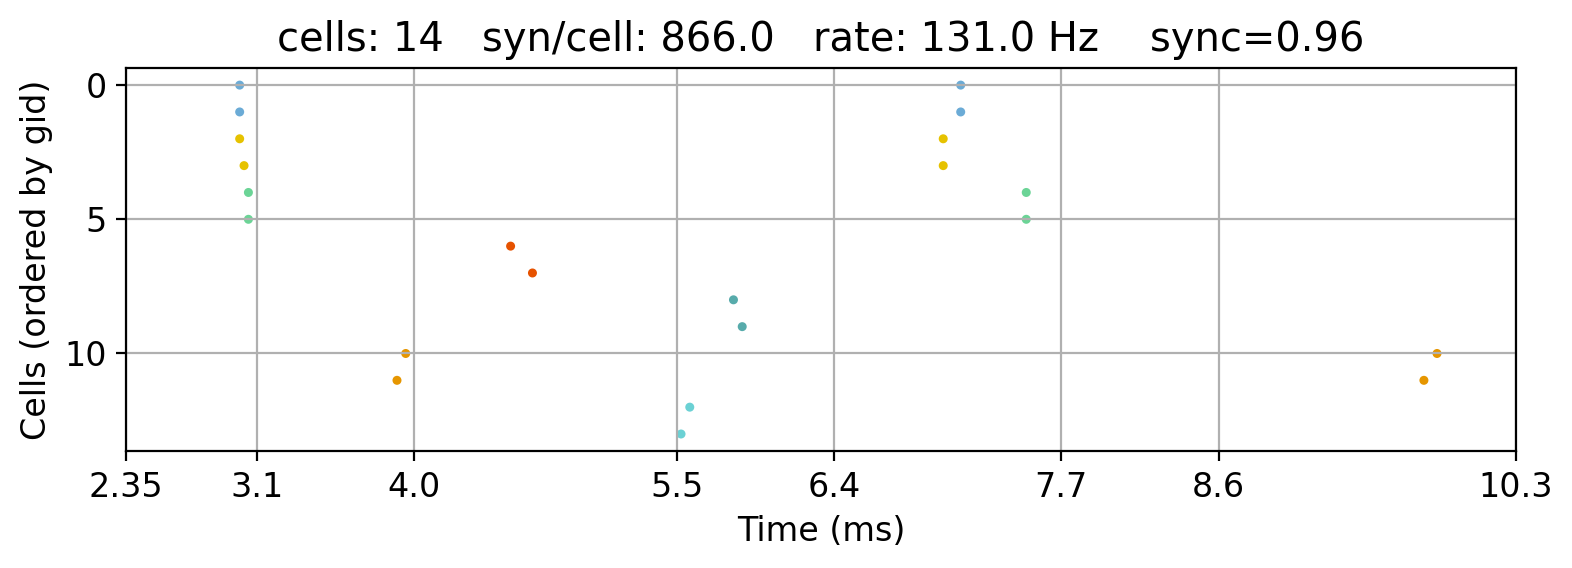

In [17]:
timeRange = [500.,512]
sim.analysis.plotRaster(**{'include': list(netParams.popParams.keys())[0:7],'saveFig': False, 'showFig': False, 'popRates': True,'orderInverse': True, 'labels': None,
                           'timeRange': timeRange, 'figSize': (8,3), 'fontSize':8, 'lw': 1, 'markerSize':1, 'marker': 'o', 'dpi': 200})
# plt.xticks(np.linspace(500.5,511.5,23))
plt.xticks(500.+np.array([2.35, 3.1, 4.0, 5.5, 6.4, 7.7, 8.6, 10.3]),np.array([2.35, 3.1, 4.0, 5.5, 6.4, 7.7, 8.6, 10.3]))
# plt.xticks(300+np.array([2.15, 2.3, 2.45, 2.75, 3.1, 4.0]),np.array([2.15, 2.3, 2.45, 2.75, 3.1, 4.0]))
plt.grid(True)
plt.show()

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

excel_file_path = "Spike_trains_steps_L4_elife_Aric.xlsx"

df_rs = pd.read_excel(excel_file_path, sheet_name="RS")
df_fs = pd.read_excel(excel_file_path, sheet_name="FS")
df_rip = pd.read_excel(excel_file_path, sheet_name="Ripplets")
df_rip2 = pd.read_excel(excel_file_path, sheet_name="Ripplets2")

# print("DataFrame for sheet 'RS':")
# print(df_rs.head())
# print("\nDataFrame for sheet 'FS':")
# print(df_fs.head())
# print("\nDataFrame for sheet 'Ripplets':")
# print(df_rip.head())
# print("\nDataFrame for sheet 'Ripplets2':")
# print(df_rip2.head())

# -------------------------------------------------------------------------------- #
# Original time and voltage
t_orig = df_rip2['042021'].values
v_orig = df_rip2['FS 2 ms stim IC'].values

# Create new time array with double the number of points (higher resolution)
t_highres = np.linspace(t_orig[0], t_orig[-1], 4 * len(t_orig) - 1)

# Interpolate using cubic interpolation
interp_func = interp1d(t_orig, v_orig, kind='cubic')
v_highres = interp_func(t_highres)

# -------------------------------------------------------------------------------- #
t_orig2 = df_rip['031820_DFI_P41'].values
v_orig2 = df_rip['FS 5 ms stim'].values

# Create new time array with double the number of points (higher resolution)
t_highres2 = np.linspace(t_orig2[0], t_orig2[-1], 4 * len(t_orig2) - 1)
# Interpolate using cubic interpolation
interp_func2 = interp1d(t_orig2, v_orig2, kind='cubic')
v_highres2 = interp_func2(t_highres2)   

# -------------------------------------------------------------------------------- #
# Original time and voltage
t_orig3 = df_rip2['042021'].values
v_orig3 = df_rip2['RS 2 ms stim IC'].values

# Create new time array with double the number of points (higher resolution)
t_highres3 = np.linspace(t_orig3[0], t_orig3[-1], 4 * len(t_orig3) - 1)
# Interpolate using cubic interpolation
interp_func3 = interp1d(t_orig3, v_orig3, kind='cubic')
v_highres3 = interp_func3(t_highres3)   

# -------------------------------------------------------------------------------- #

t_orig4 = df_rip['102920_DFI_P36'].values
v_orig4 = df_rip['RS 2 ms stim'].values

# Create new time array with double the number of points (higher resolution)
t_highres4 = np.linspace(t_orig4[0], t_orig4[-1], 4 * len(t_orig4) - 1)
# Interpolate using cubic interpolation
interp_func4 = interp1d(t_orig4, v_orig4, kind='cubic')
v_highres4 = interp_func4(t_highres4)       
# -------------------------------------------------------------------------------- #

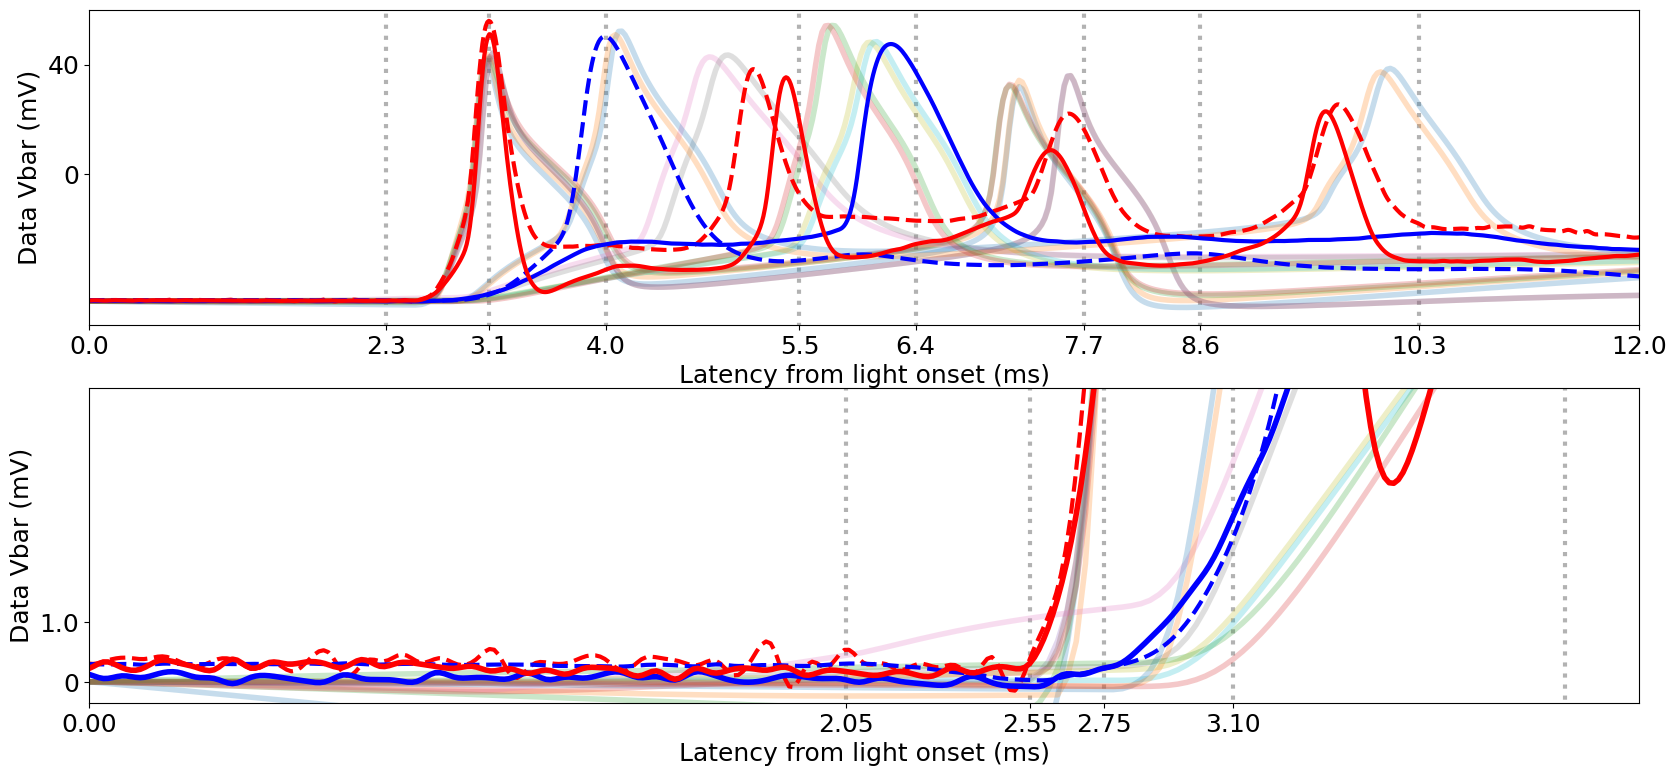

In [19]:
plt.figure(figsize=(20, 9))

plt.subplot(2, 1, 1)
plt.vlines(x=[2.3, 3.1, 4.0, 5.5, 6.4, 7.7, 8.6, 10.3],ymin=-80, ymax=40, colors='k', linestyles='dotted', linewidth=3,  alpha=0.3)
for cell in sim.simData['V_soma'].keys():
    if 'cell' in cell:   
        try:
            plt.plot(sim.simData['t']-500., sim.simData['V_soma'][cell]-sim.simData['V_soma'][cell][20000]-66.4, linewidth=4, alpha=0.25, label=cell)
        except:
            print(cell) 
            pass
plt.plot(t_highres2-1.2, v_highres2+4-3.7, color='red', linewidth=3, linestyle='--')
plt.plot(t_highres4-0.5, v_highres4+3-3.7, color='blue', linewidth=3, linestyle='--')
plt.plot(t_highres3-1.01, v_highres3+10, color='blue', linewidth=3)
plt.plot(t_highres-1.01, v_highres+3, color='red', linewidth=3)
plt.ylabel('Data Vbar (mV)', size=18)
plt.xlim(0.0, 12)
plt.ylim(-75.0, 40)
plt.xticks([0, 2.3, 3.1, 4.0, 5.5, 6.4, 7.7, 8.6, 10.3, 12], size=18);
plt.xlabel('Latency from light onset (ms)', size=18);
plt.yticks([-20,20], [0,40], size=18);
# plt.ylim(-67., -65.5);
plt.subplot(2, 1, 2)
plt.vlines(x=[2.05, 2.55, 2.75, 3.1, 4.0, 5.5, 6.4, 7.7, 8.6, 10.3],ymin=-80, ymax=40, colors='k', linestyles='dotted', linewidth=3,  alpha=0.3)
for cell in sim.simData['V_soma'].keys():
    if 'cell' in cell:   
        try:
            plt.plot(sim.simData['t']-500., sim.simData['V_soma'][cell]-sim.simData['V_soma'][cell][20000]-66.4, linewidth=4, alpha=0.25, label=cell)
        except:
            print(cell) 
            pass
plt.plot(t_highres2-1.2, v_highres2+4-3.7, color='red', linewidth=3, linestyle='--')
plt.plot(t_highres4-0.5, v_highres4+3-3.7, color='blue', linewidth=3, linestyle='--')
plt.plot(t_highres3-1.01, v_highres3+10, color='blue', linewidth=4)
plt.plot(t_highres-1.01, v_highres+3, color='red', linewidth=4)
plt.ylabel('Data Vbar (mV)', size=18)
plt.xlim(0.0, 4.2)
plt.xticks([0,2.05, 2.55, 2.75, 3.1], size=18);
plt.ylim(-66.75, -61.5);
plt.yticks([-66.4, -65.4],[0,1.0], size=18);
plt.xlabel('Latency from light onset (ms)', size=18);
# plt.legend(fontsize=12)

# plt.savefig('Fig_FS_RS_vopt_2ms_stim.png', dpi=300)

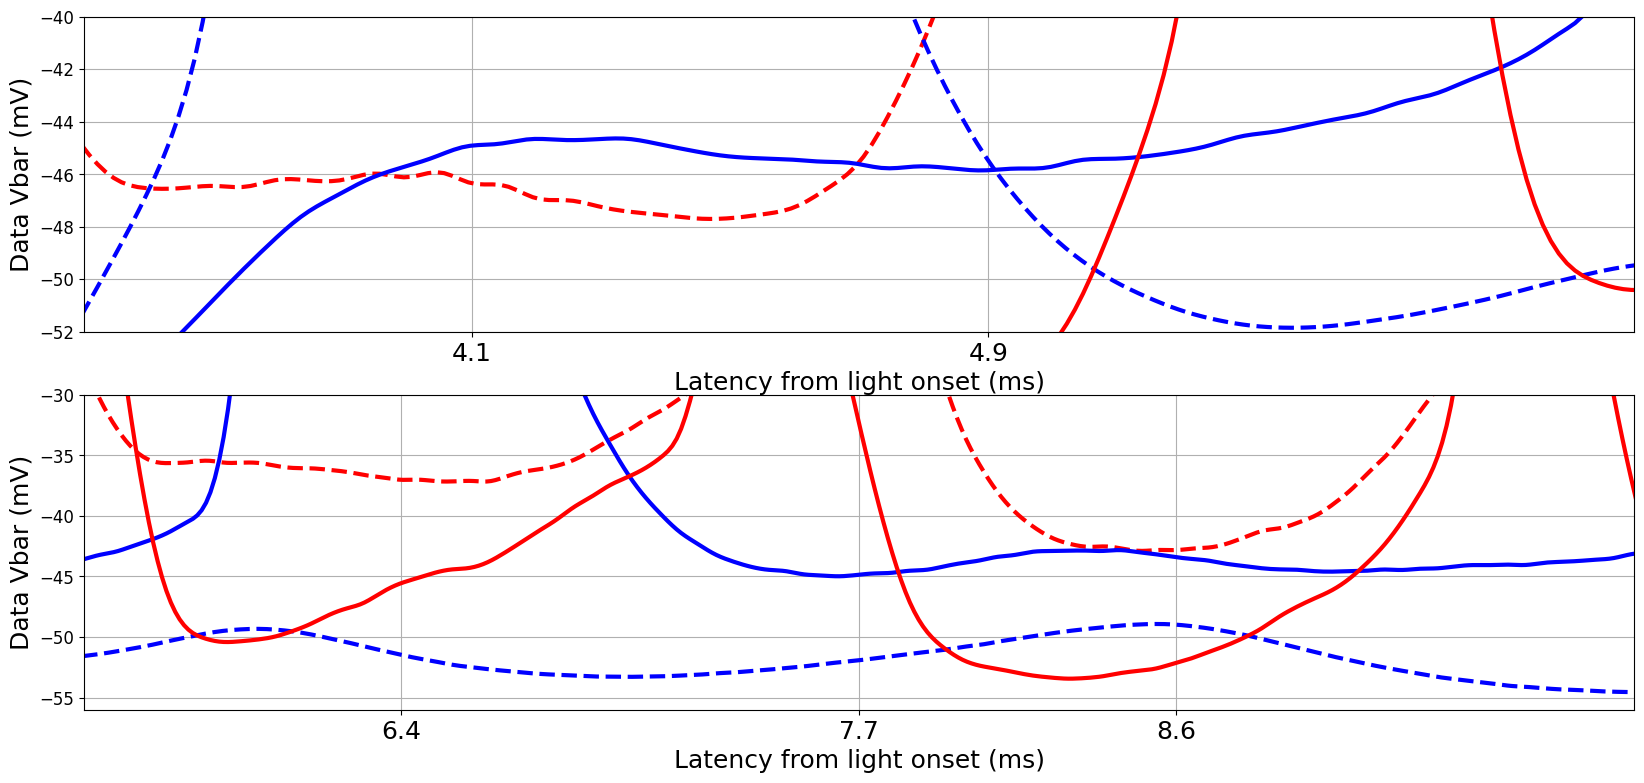

In [20]:
plt.figure(figsize=(20, 9))

plt.subplot(2, 1, 1)
plt.plot(t_highres2-1.2, v_highres2+4-3.7, color='red', linewidth=3, linestyle='--')
plt.plot(t_highres4-0.5, v_highres4+3-3.7, color='blue', linewidth=3, linestyle='--')
plt.plot(t_highres3-1.01, v_highres3+10, color='blue', linewidth=3)
plt.plot(t_highres-1.01, v_highres+3, color='red', linewidth=3)
plt.ylabel('Data Vbar (mV)', size=18)
plt.xlim(0.0, 12)
plt.ylim(-75.0, 40)
plt.xticks([0, 2.3, 3.1, 4.1, 4.9, 6.4, 7.7, 8.6, 10.3, 12], size=18);
plt.xlabel('Latency from light onset (ms)', size=18);
# plt.yticks([-20,20], [0,40], size=18);
plt.xlim(3.5, 5.9)
plt.grid(True)
plt.ylim(-52., -40.);
plt.subplot(2, 1, 2)
plt.plot(t_highres2-1.2, v_highres2+4-3.7, color='red', linewidth=3, linestyle='--')
plt.plot(t_highres4-0.5, v_highres4+3-3.7, color='blue', linewidth=3, linestyle='--')
plt.plot(t_highres3-1.01, v_highres3+10, color='blue', linewidth=3)
plt.plot(t_highres-1.01, v_highres+3, color='red', linewidth=3)
plt.ylabel('Data Vbar (mV)', size=18)
plt.xlim(0.0, 12)
plt.ylim(-75.0, 40)
plt.xticks([0, 2.3, 3.1, 4.1, 4.9, 6.4, 7.7, 8.6, 10.3, 12], size=18);
plt.xlabel('Latency from light onset (ms)', size=18);
# plt.yticks([-20,20], [0,40], size=18);
plt.xlim(5.5, 9.9)
plt.grid(True)
plt.ylim(-56., -30.);

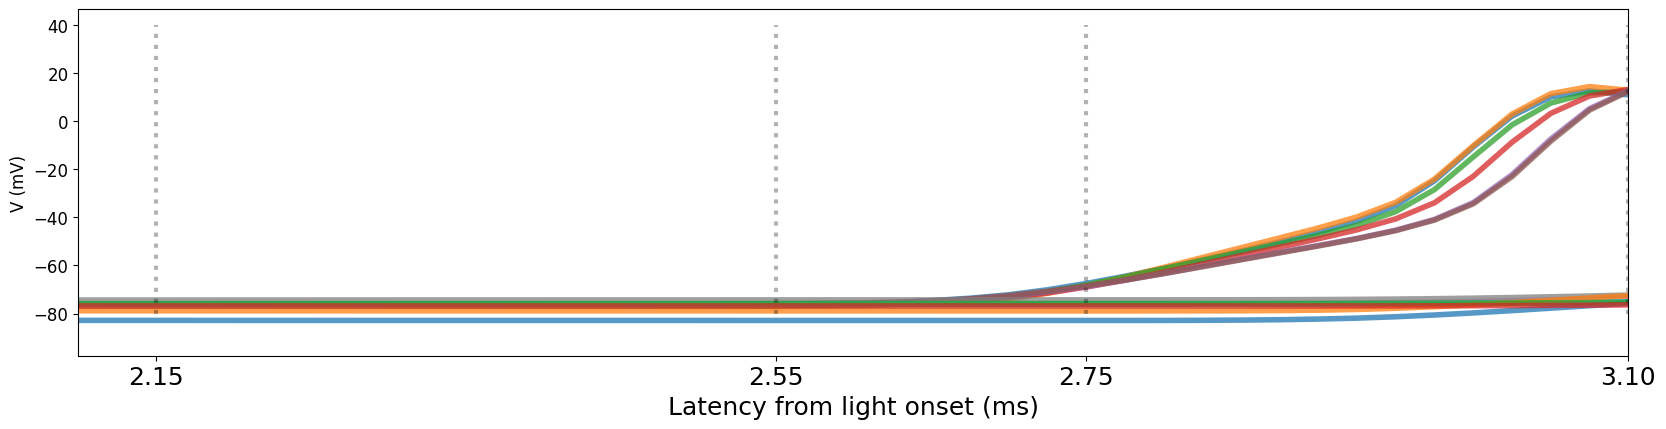

In [21]:
fig = plt.figure(figsize=(20, 4.5))
# plt.vlines(x=[0,0.3,1.45,3.75],ymin=-80, ymax=40, colors='cyan', linestyles='dashed', linewidth=3)
for cell in sim.simData['V_soma'].keys():
    if 'cell' in cell:   
        try:
            plt.plot(sim.simData['t']-500., sim.simData['V_soma'][cell]-sim.simData['V_soma'][cell][12100]-76.0, linewidth=4, alpha=0.75, label=cell)
        except:
            print(cell) 
            pass
# plt.legend(fontsize=12)
plt.xlim(2.10, 3.)
# plt.ylim(-76.5, -75.6)
plt.ylabel('V (mV)')
# plt.vlines(x=np.array([2.05, 2.55, 2.75, 3.1, 4.0, 5.5, 6.4, 7.7, 8.6, 10.3]),ymin=-80, ymax=40, colors='k', linestyles='dotted', linewidth=3,  alpha=0.3)
plt.xlabel('Latency from light onset (ms)', size=18);
# plt.xticks(np.array([0, 2.05, 2.55, 2.75, 3.1, 4.0, 5.5, 6.4, 7.7, 8.6, 10.3, 15]), size=18);
plt.vlines(x=np.array([2.15, 2.55, 2.75, 3.1]),ymin=-80, ymax=40, colors='k', linestyles='dotted', linewidth=3,  alpha=0.3)
plt.xticks(np.array([2.15, 2.55, 2.75, 3.1]), size=18);

In [22]:
# for ii in range(0,10*len(node_gid),5):
#         sim.analysis.plotShape(includePre= [ii], includePost= [ii], 
#                 includeAxon=False, showSyns=True, showElectrodes=False, 
#                 cvar= 'voltage', dist=0.7, elev=0, azim=-90, 
#                 axisLabels=True, synStyle='o', 
#                 clim= [50.0, 100.0], showFig=False, synSize=4, saveFig=False, figSize=(6,6));

In [23]:
# sim.analysis.plotShape(includePre= [ii for ii in range(len(10*node_gid))], includePost= [ii for ii in range(10*len(node_gid))], 
#                        includeAxon=False, showSyns=True, showElectrodes=False,
#     cvar= 'voltage', dist=0.6, elev=0, azim=-90, 
#     axisLabels=True, synStyle='o', 
#     clim= [50.0, 100.0], showFig=False, synSize=4, saveFig=False, figSize=(12,12))

Plotting 2D representation of network cell locations and connections...
Plotting 2D representation of network cell locations and connections...


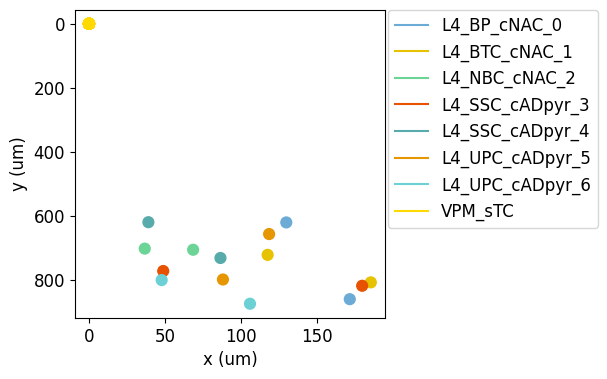

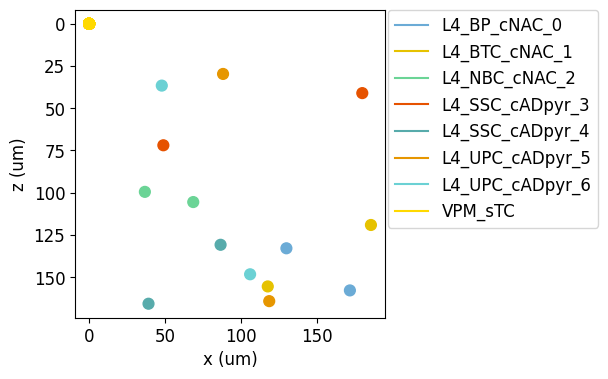

In [24]:
sim.analysis.plot2Dnet(include= [ii for ii in range(len(10*node_gid))], figSize=(4,4), showConns=False, view='xy', fontSize=12, saveFig=False, showFig=False);
sim.analysis.plot2Dnet(include= [ii for ii in range(len(10*node_gid))], figSize=(4,4), showConns=False, view='xz', fontSize=12, saveFig=False, showFig=False);